In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# XOR 数据
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

Y = np.array([[0],[1],[1],[0]], dtype=float)

m = X.shape[0]

In [5]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [6]:
np.random.seed(0)

W1 = np.random.randn(2, 4) * 0.1
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 4) * 0.1
b2 = np.zeros((1, 4))

W3 = np.random.randn(4, 3) * 0.1
b3 = np.zeros((1, 3))

W4 = np.random.randn(3, 1) * 0.1
b4 = np.zeros((1, 1))

In [7]:
def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    Y_hat = sigmoid(Z4)

    cache = (Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat)
    return Y_hat, cache

In [8]:
def backward(X, Y, cache):
    global W1, W2, W3, W4

    Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat = cache
    m = X.shape[0]

    # 输出层
    dZ4 = Y_hat - Y
    dW4 = (A3.T @ dZ4) / m
    db4 = np.sum(dZ4, axis=0, keepdims=True) / m

    # 第3层
    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # 第2层
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # 第1层
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [11]:
def copy_params():
    return (W1.copy(), b1.copy(), W2.copy(), b2.copy(), W3.copy(), b3.copy(), W4.copy(), b4.copy())

In [12]:
epochs = 3000
lr = 0.08
snapshot_every = 150
snapshots = [(0, copy_params())]

for epoch in range(1, epochs + 1):
    Yhat, cache = forward(X)
    grads = backward(X, Y, cache)
    dW1, db1g, dW2, db2g, dW3, db3g, dW4, db4g = grads
    W1 -= lr * dW1; b1 -= lr * db1g
    W2 -= lr * dW2; b2 -= lr * db2g
    W3 -= lr * dW3; b3 -= lr * db3g
    W4 -= lr * dW4; b4 -= lr * db4g
    if epoch % snapshot_every == 0:
        snapshots.append((epoch, copy_params()))

x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                     np.linspace(y_min, y_max, 120))
grid = np.c_[xx.ravel(), yy.ravel()]

In [13]:
def predict_grid(Xin, params):
    W1_, b1_, W2_, b2_, W3_, b3_, W4_, b4_ = params
    Z1 = Xin @ W1_ + b1_; A1 = relu(Z1)
    Z2 = A1 @ W2_ + b2_; A2 = relu(Z2)
    Z3 = A2 @ W3_ + b3_; A3 = relu(Z3)
    Z4 = A3 @ W4_ + b4_
    return sigmoid(Z4)

In [10]:
Y_hat, _ = forward(X)

print("\n预测结果：")
for i in range(len(X)):
    print(X[i], "->", Y_hat[i,0])


预测结果：
[0. 0.] -> 0.00021021915961794252
[0. 1.] -> 0.9999357677042473
[1. 0.] -> 0.9999492844102892
[1. 1.] -> 4.020601666550328e-06


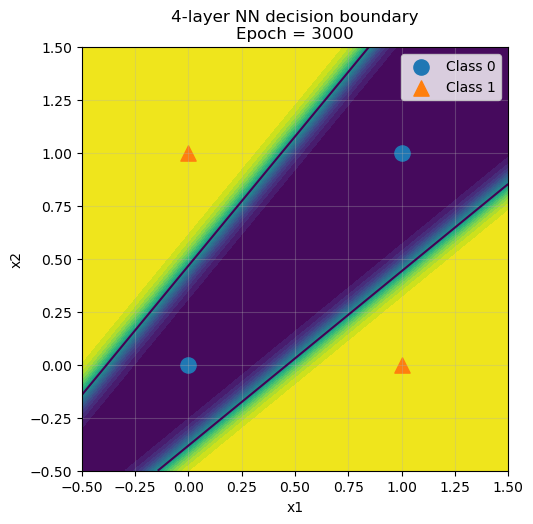

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(5.5, 5.5))
def update(frame_idx):
    ax.clear()
    epoch, params = snapshots[frame_idx]
    probs = predict_grid(grid, params).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20)
    ax.contour(xx, yy, probs, levels=[0.5])
    ax.scatter(X[Y[:,0] == 0, 0], X[Y[:,0] == 0, 1], s=120, marker='o', label='Class 0')
    ax.scatter(X[Y[:,0] == 1, 0], X[Y[:,0] == 1, 1], s=120, marker='^', label='Class 1')
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(f"4-layer NN decision boundary\nEpoch = {epoch}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

anim = FuncAnimation(fig, update, frames=len(snapshots), interval=280)
# anim.save("decision_boundary_4layer_xor.gif", writer=PillowWriter(fps=3))

